In [2]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from visualisation.plotting import coupled_label_plot, color_code_labels
from utils.analysis import get_query_string_hyps_filter, prepare_labels_df, rotate_umap, load_dbscan_labels

In [3]:
# Plot settings
xmap = {"n_clusters": "Number of clusters", "eps": "Epsilon", "min_samples": "Minimum number of samples"}
score_name_map = {"calinski_harabasz": "Calinski-Harabasz Score", "silhouette": "Silhouette Score", "davies_bouldin": "Davies-Bouldin Score", "nnoise": "Noise [%]", "nclusters": "Number of Clusters",
                 "kdbcv": "k-DBCV", "cdr": "CDR", "cvnn_hal": "CVNN Halkidi"}
c_blue = sns.color_palette("tab10")[0]
c_orange = sns.color_palette("tab10")[1]

In [4]:
def plot_score(df, x, legend_loc=None):
    """ Plot Calinski-Harabasz, Silhouette and Davies-Bouldin scores as line plots. """
    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8.27, 8.27*0.6))
    axs = axs.flatten()

    # Plot lines
    l1 = sns.lineplot(df[df["preprocessing"] == "robust"], x=x, y="calinski_harabasz", ax=axs[0], c=c_blue, label="Robust")
    l2 = sns.lineplot(df[df["preprocessing"] == "robust"], x=x, y="davies_bouldin", ax=axs[1], c=c_blue, label="Robust")
    l3 = sns.lineplot(df[df["preprocessing"] == "robust"], x=x, y="silhouette", ax=axs[2], c=c_blue, label="Robust")
    
    l4 = sns.lineplot(df[df["preprocessing"] == "robust_umap"], x=x, y="calinski_harabasz", ax=axs[0], c=c_orange, label="Robust-UMAP")
    l5 = sns.lineplot(df[df["preprocessing"] == "robust_umap"], x=x, y="davies_bouldin", ax=axs[1], c=c_orange, label="Robust-UMAP")
    l6 = sns.lineplot(df[df["preprocessing"] == "robust_umap"], x=x, y="silhouette", ax=axs[2], c=c_orange, label="Robust-UMAP")

    l7 = sns.lineplot(df[df["preprocessing"] == "robust"], x=x, y="kdbcv", ax=axs[3], c=c_blue, label="Robust")
    l8 = sns.lineplot(df[df["preprocessing"] == "robust"], x=x, y="cvnn_hal", ax=axs[4], c=c_blue, label="Robust")
    l9 = sns.lineplot(df[df["preprocessing"] == "robust"], x=x, y="cdr", ax=axs[5], c=c_blue, label="Robust")

    l10 = sns.lineplot(df[df["preprocessing"] == "robust_umap"], x=x, y="kdbcv", ax=axs[3], c=c_orange, label="Robust-UMAP")
    l11 = sns.lineplot(df[df["preprocessing"] == "robust_umap"], x=x, y="cvnn_hal", ax=axs[4], c=c_orange, label="Robust-UMAP")
    l12 = sns.lineplot(df[df["preprocessing"] == "robust_umap"], x=x, y="cdr", ax=axs[5], c=c_orange, label="Robust-UMAP")
   
    # Define labels
    l1.set_xlabel(None)
    l1.set_ylabel(None)
    l1.set_title(r"Calinski-Harabasz Score $\uparrow$", fontsize=11)
    l1.tick_params(labelsize=8)
    l1.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l2.set_xlabel(None)
    l2.set_ylabel(None)
    l2.set_title(r"Davies-Bouldin Score $\downarrow$", fontsize=11)
    l2.tick_params(labelsize=8)
    l2.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l3.set_xlabel(None)
    l3.set_ylabel(None)
    l3.set_title(r"Silhouette Score $\uparrow$", fontsize=11)
    l3.tick_params(labelsize=8)
    l3.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l7.set_xlabel(None)
    l7.set_ylabel(None)
    l7.set_title(r"k-DBCV $\uparrow$", fontsize=11)
    l7.tick_params(labelsize=8)
    l7.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l8.set_xlabel(None)
    l8.set_ylabel(None)
    l8.set_title(r"CVNN Halkidi $\uparrow$", fontsize=11)
    l8.tick_params(labelsize=8)
    l8.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l9.set_xlabel(None)
    l9.set_ylabel(None)
    l9.set_title(r"CDR $\downarrow$", fontsize=11)
    l9.tick_params(labelsize=8)
    l9.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    fig.supxlabel(xmap[x], fontsize=11, y=0.04)
    
    plt.tight_layout()

In [5]:
def find_steepest_gradient(df, value_col="calinski_harabasz"):
    """ Find steepest gradient for DBSCAN in an eps-min_samples heatmap using value_col as value column. """
    temp = df.copy()
    
    # Normalise columns for consistent scaling
    temp['eps_norm'] = (temp['eps'] - temp['eps'].min()) / (temp['eps'].max() - temp['eps'].min())
    temp['min_samples_norm'] = (temp['min_samples'] - temp['min_samples'].min()) / (temp['min_samples'].max() - temp['min_samples'].min())
    temp['calinski_norm'] = (temp[value_col] - temp[value_col].min()) / (temp[value_col].max() - temp[value_col].min())
    
    # Pivot to create a 2D grid
    grid = temp.pivot(index='min_samples_norm', columns='eps_norm', values='calinski_norm')
    grid = grid.interpolate(method='linear', axis=0).interpolate(method='linear', axis=1)  # Fill missing values

    # Calculate gradients
    grad_eps, grad_min_samples = np.gradient(grid.values)  # Numerical differentiation

    # Compute gradient magnitude
    grad_magnitude = np.sqrt(grad_eps**2 + grad_min_samples**2)

    # Find the index of the maximum gradient
    max_idx = np.unravel_index(np.argmax(grad_magnitude), grad_magnitude.shape)
    max_min_samples_norm = grid.index[max_idx[0]]
    max_eps_norm = grid.columns[max_idx[1]]

    # Map back to original scale
    max_eps = max_eps_norm * (temp['eps'].max() - temp['eps'].min()) + temp['eps'].min()
    max_min_samples = max_min_samples_norm * (temp['min_samples'].max() - temp['min_samples'].min()) + temp['min_samples'].min()

    return max_eps, max_min_samples

In [6]:
def plot_heatmap(df, x="min_samples", y="eps", color="nclusters", title="Sweep of DBSAN (on original data)", vmax=None, mask=None, annot=True, patch=None):
    """ Plot heatmap using 2 variables and compute steepest gradient. """
    df_temp = df.copy()
    df_temp = df_temp.sort_values([y, x])

    # Define heatmap fields
    idx = df_temp[y].unique()
    cols = df_temp[x].unique()
    field = pd.DataFrame(df_temp[color].to_numpy().reshape(len(idx), len(cols)), index=idx, columns=cols)

    # Apply mask (if some fields are not supposed to be shown)
    if mask is not None:
        field = field[mask]

    # Heatmap plot
    h = sns.heatmap(data=field, cbar_kws={'label': score_name_map[color]}, annot=annot, fmt='g', cmap="gray", vmax=vmax)
    plt.gca().invert_yaxis()
    if patch:
        h.add_patch(Rectangle((np.where(cols == patch[1])[0][0], np.where(idx == patch[0])[0][0]), 1, 1, fill=False, edgecolor="red", lw=2))
    plt.xlabel(x)  
    plt.ylabel(y) 
    plt.title(title)  
    plt.tick_params(axis='both', which='minor')  
    plt.tight_layout()

    # Compute steepest gradient
    steepest_gradient_eps, steepest_gradient_min_samples = find_steepest_gradient(df, value_col=color)

    return field, (steepest_gradient_eps, steepest_gradient_min_samples)

# Load data

In [71]:
# Load scores
df_kmeans = pd.read_csv(f"{config.output_dir_clustering}internal_validation_kmeans.csv")
df_ward = pd.read_csv(f"{config.output_dir_clustering}internal_validation_ward.csv")
df_dbscan = pd.read_csv(f"{config.output_dir_clustering}internal_validation_dbscan.csv")
df_spatial = pd.read_csv(f"{config.output_dir_clustering}internal_validation_spatial_ward.csv")

In [75]:
# Load labels (from iteration 0, store labels from different preproccessings in different columns)
df_kmeans_labels = pd.read_csv(f"{config.output_dir_clustering}labels_kmeans.csv")
df_kmeans_labels = prepare_labels_df(df_kmeans_labels, iteration=0)

df_ward_labels = pd.read_csv(f"{config.output_dir_clustering}labels_ward.csv")
df_ward_labels = prepare_labels_df(df_ward_labels, iteration=0)

df_dbscan_labels = load_dbscan_labels(iteration=0)
df_dbscan_labels = prepare_labels_df(df_dbscan_labels)

df_spatial_labels = pd.read_csv(f"{config.output_dir_clustering}labels_spatial_ward.csv")
df_spatial_labels = prepare_labels_df(df_spatial_labels, iteration=0)

# Compare across algorithms
Using the finally selected hyperparameter combinations, compare the CVIs for the algorithms. 

In [97]:
# Filter the score data for the final hyperparameter combinations
# Kmeans original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.kmeans_original_hyps, preproc="robust")
ko = df_kmeans.query(query_str)

# Kmeans embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.kmeans_umap_hyps, preproc="robust_umap")
ke = df_kmeans.query(query_str)

# Ward original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.ward_original_hyps, preproc="robust")
wo = df_ward.query(query_str)

# Ward embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.ward_umap_hyps, preproc="robust_umap")
we = df_ward.query(query_str)

# DBSCAN original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_original_hyps, preproc="robust", float_tol=1e-8)
do = df_dbscan.query(query_str)

# DBSCAN embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_umap_hyps, preproc="robust_umap", float_tol=1e-8)
de = df_dbscan.query(query_str)

# Spatial Ward original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.spatial_original_hyps, preproc="robust_umap", float_tol=1e-8)
so = df_spatial.query(query_str)

# Spatial ward embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.spatial_umap_hyps, preproc="robust_umap", float_tol=1e-8)
se = df_spatial.query(query_str)

In [98]:
# Spatial Ward original
query_str = get_query_string_hyps_filter(hyp_dict={"n_clusters": 2, "linkage": "ward"}, preproc="robust_umap", float_tol=1e-8)
so = df_spatial.query(query_str)

# Spatial ward embedding
query_str = get_query_string_hyps_filter(hyp_dict={"n_clusters": 12, "linkage": "ward"}, preproc="robust_umap", float_tol=1e-8)
se = df_spatial.query(query_str)

In [99]:
print("Average scores")
print("\nKMeans on original: ")
print(f'  Calinski-Harabasz: {ko["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {ko["davies_bouldin"].mean().round(2)}\n  Silhouette: {ko["silhouette"].mean().round(2)}\n  k-DBCV: {ko["kdbcv"].mean()}\n  CVNN Halkidi: {ko["cvnn_hal"].mean().round(2)}\n  CDR: {ko["cdr"].mean().round(2)}')
print("\nKMeans on UMAP: ")
print(f'  Calinski-Harabasz: {ke["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {ke["davies_bouldin"].mean().round(2)}\n  Silhouette: {ke["silhouette"].mean().round(2)}\n  k-DBCV: {ke["kdbcv"].mean()}\n  CVNN Halkidi: {ke["cvnn_hal"].mean().round(2)}\n  CDR: {ke["cdr"].mean().round(2)}')

print("\nWard on original: ")
print(f'  Calinski-Harabasz: {wo["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {wo["davies_bouldin"].mean().round(2)}\n  Silhouette: {wo["silhouette"].mean().round(2)}\n  k-DBCV: {wo["kdbcv"].mean()}\n  CVNN Halkidi: {wo["cvnn_hal"].mean().round(2)}\n  CDR: {wo["cdr"].mean().round(2)}')
print("\nWard on UMAP: ")
print(f'  Calinski-Harabasz: {we["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {we["davies_bouldin"].mean().round(2)}\n  Silhouette: {we["silhouette"].mean().round(2)}\n  k-DBCV: {we["kdbcv"].mean()}\n  CVNN Halkidi: {we["cvnn_hal"].mean().round(2)}\n  CDR: {we["cdr"].mean().round(2)}')

print("\nDBSCAN on original: ")
print(f'  Calinski-Harabasz: {do["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {do["davies_bouldin"].mean().round(2)}\n  Silhouette: {do["silhouette"].mean().round(2)}\n  k-DBCV: {do["kdbcv"].mean()}\n  CVNN Halkidi: {do["cvnn_hal"].mean().round(2)}\n  CDR: {do["cdr"].mean().round(2)}')
print("\nDBSCAN on UMAP: ")
print(f'  Calinski-Harabasz: {de["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {de["davies_bouldin"].mean().round(2)}\n  Silhouette: {de["silhouette"].mean().round(2)}\n  k-DBCV: {de["kdbcv"].mean()}\n  CVNN Halkidi: {de["cvnn_hal"].mean().round(2)}\n  CDR: {de["cdr"].mean().round(2)}')

print("\nSpatial Ward on original: ")
print(f'  Calinski-Harabasz: {so["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {so["davies_bouldin"].mean().round(2)}\n  Silhouette: {so["silhouette"].mean().round(2)}\n  k-DBCV: {so["kdbcv"].mean()}\n  CVNN Halkidi: {so["cvnn_hal"].mean().round(2)}\n  CDR: {so["cdr"].mean().round(2)}')
print("\nSpatial Ward on UMAP: ")
print(f'  Calinski-Harabasz: {se["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {se["davies_bouldin"].mean().round(2)}\n  Silhouette: {se["silhouette"].mean().round(2)}\n  k-DBCV: { se["kdbcv"].mean()}\n  CVNN Halkidi: {se["cvnn_hal"].mean().round(2)}\n  CDR: {se["cdr"].mean().round(2)}')

Average scores

KMeans on original: 
  Calinski-Harabasz: 28296.0
  Davies-Bouldin: 0.76
  Silhouette: 0.57
  k-DBCV: -1.0
  CVNN Halkidi: 2.49
  CDR: 0.59

KMeans on UMAP: 
  Calinski-Harabasz: 26049.0
  Davies-Bouldin: 0.99
  Silhouette: 0.31
  k-DBCV: -0.7781318277410215
  CVNN Halkidi: 4.85
  CDR: 0.34

Ward on original: 
  Calinski-Harabasz: 47112.0
  Davies-Bouldin: 0.17
  Silhouette: 0.91
  k-DBCV: -1.0
  CVNN Halkidi: 2.62
  CDR: 0.59

Ward on UMAP: 
  Calinski-Harabasz: 18827.0
  Davies-Bouldin: 1.12
  Silhouette: 0.24
  k-DBCV: -0.7023520317806997
  CVNN Halkidi: 3.82
  CDR: 0.34

DBSCAN on original: 
  Calinski-Harabasz: 115.0
  Davies-Bouldin: 1.74
  Silhouette: -0.64
  k-DBCV: -1.0
  CVNN Halkidi: 4.85
  CDR: 0.7

DBSCAN on UMAP: 
  Calinski-Harabasz: 5.0
  Davies-Bouldin: 1.16
  Silhouette: -0.73
  k-DBCV: 0.00460630030844964
  CVNN Halkidi: 155.29
  CDR: 46.64

Spatial Ward on original: 
  Calinski-Harabasz: 9407.0
  Davies-Bouldin: 1.85
  Silhouette: 0.17
  k-DBCV: -1.0

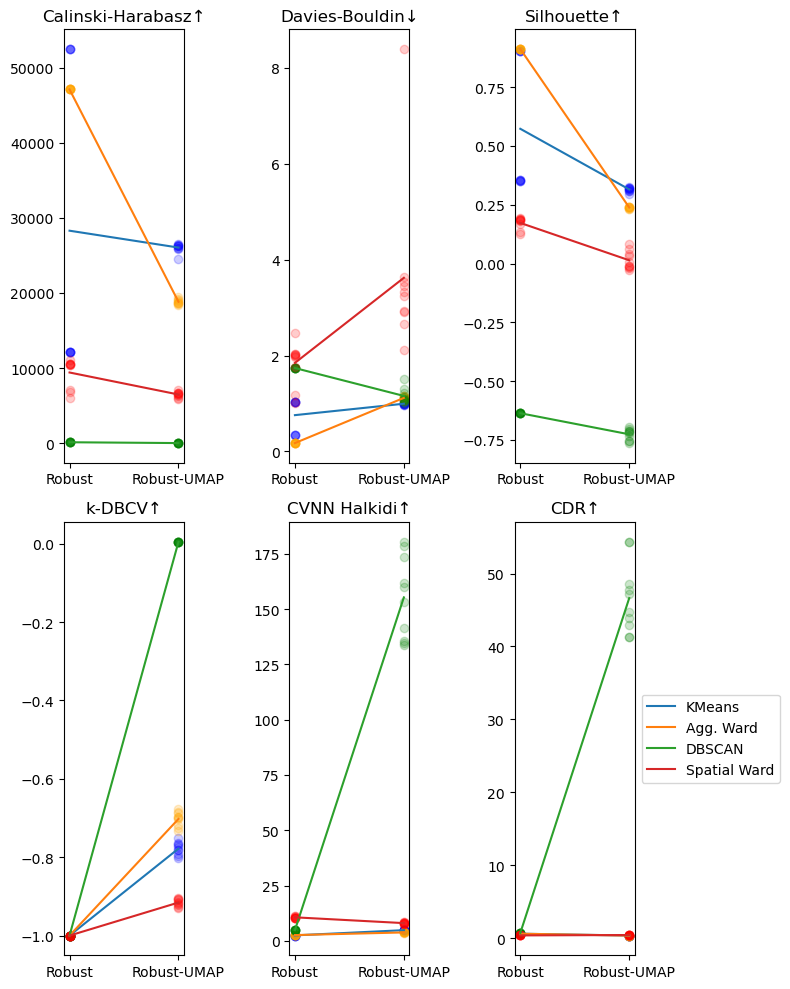

In [141]:
# Compare scores of clustering methods on both preprocessings (using final hyperparameters)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 10))
axs = axs.flatten()

alpha = 0.2
for i, score, score_name in [(0, "calinski_harabasz", "Calinski-Harabasz"), (1, "davies_bouldin", "Davies-Bouldin"), (2, "silhouette", "Silhouette"), 
                             (3, "kdbcv", "k-DBCV"), (4, "cvnn_hal", "CVNN Halkidi"), (5, "cdr", "CDR")]:
    title = score_name + "\u2191"
    if score_name == "Davies-Bouldin": 
        title = score_name + "\u2193"
    axs[i].set_title(title)
    axs[i].set_xticks([0, 1], ["Robust", "Robust-UMAP"])

    axs[i].scatter([0]*len(ko), ko[score], color="blue", alpha=alpha)
    axs[i].scatter([1]*len(ke), ke[score], color="blue", alpha=alpha)
    axs[i].plot([0, 1], [ko[score].mean(), ke[score].mean()], color="tab:blue", label="KMeans")

    axs[i].scatter([0]*len(wo), wo[score], color="orange", alpha=alpha)
    axs[i].scatter([1]*len(we), we[score], color="orange", alpha=alpha)
    axs[i].plot([0, 1], [wo[score].mean(), we[score].mean()], color="tab:orange", label="Agg. Ward")

    axs[i].scatter([0]*len(do), do[score], color="green", alpha=alpha)
    axs[i].scatter([1]*len(de), de[score], color="green", alpha=alpha)
    axs[i].plot([0, 1], [do[score].mean(), de[score].mean()], color="tab:green", label="DBSCAN")

    axs[i].scatter([0]*len(so), so[score], color="red", alpha=alpha)
    axs[i].scatter([1]*len(se), se[score], color="red", alpha=alpha)
    axs[i].plot([0, 1], [so[score].mean(), se[score].mean()], color="tab:red", label="Spatial Ward")
    
axs[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
#plt.savefig(f"{config.output_dir_plots}score_comparison.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_comparison.png", dpi=1000)
plt.show()

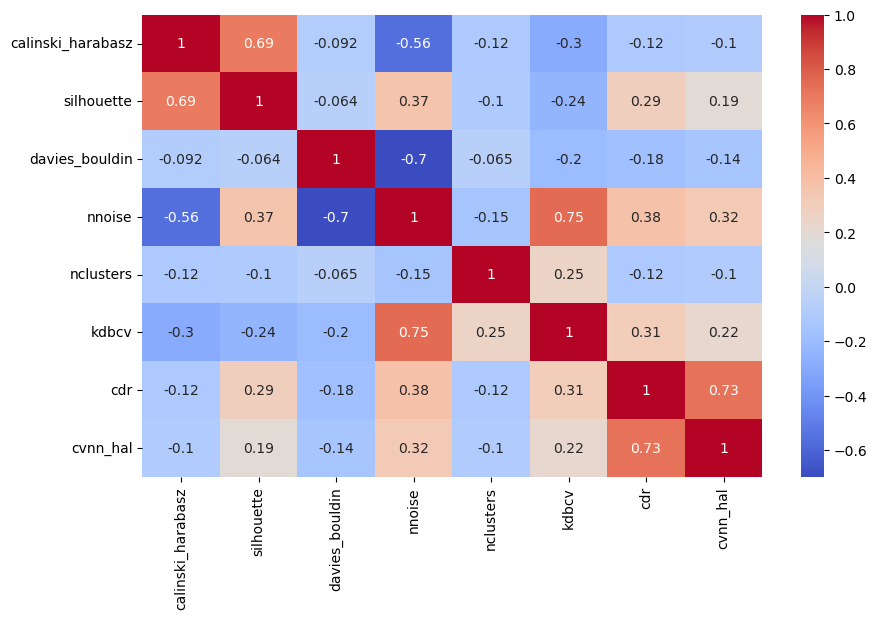

In [115]:
# Correlation between scores
final_all = pd.concat([df_kmeans, df_dbscan, df_ward, df_spatial])
sns.heatmap(final_all[score_name_map.keys()].corr(), cmap="coolwarm", annot=True)
plt.show()

# KMeans

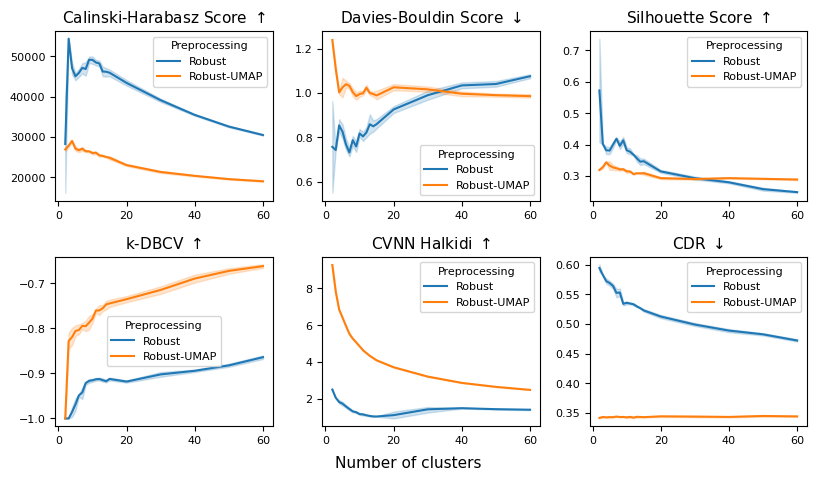

In [116]:
plot_score(df_kmeans, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_kmeans.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_kmeans.png", dpi=1000)
plt.show()

## Plots on original data (Robust)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


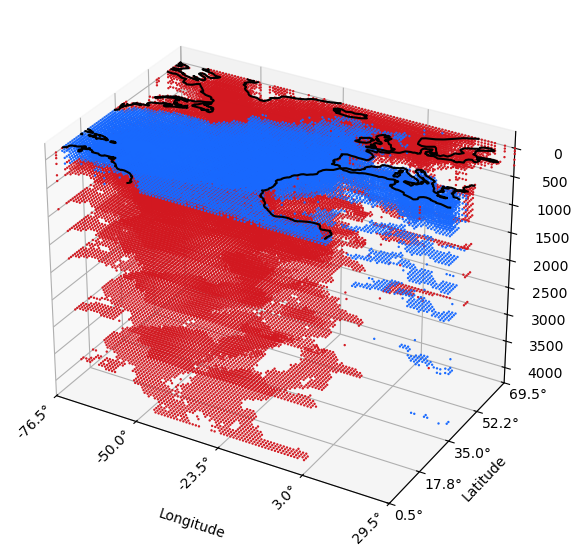

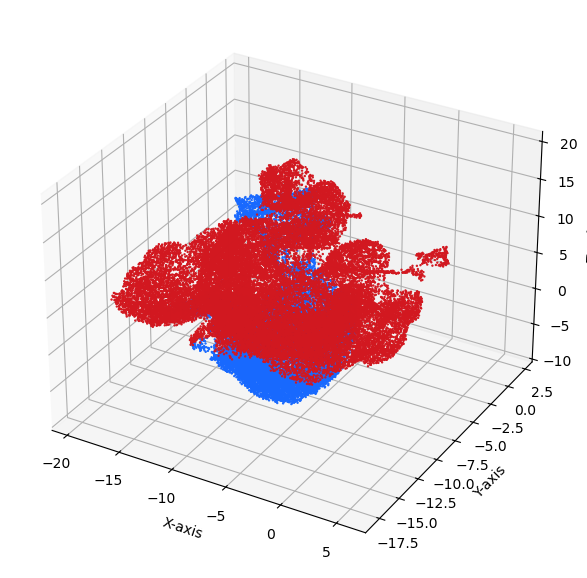

In [117]:
n_clusters = hyp_config.kmeans_original_hyps["n_clusters"]
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_kmeans_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


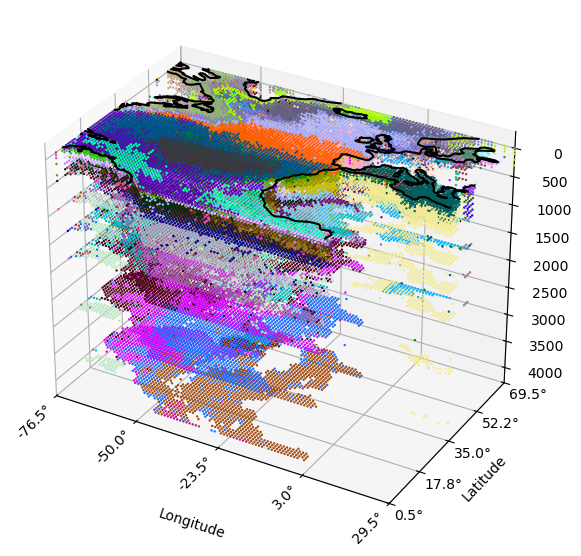

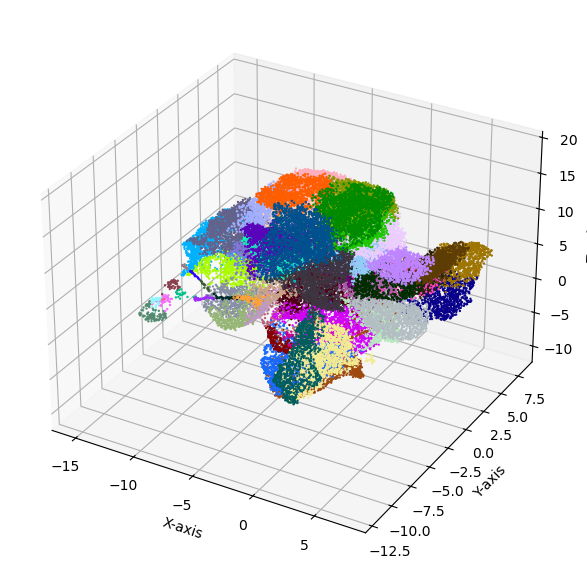

In [118]:
# Visualise highest n_clusters
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == 60]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix="_kmeans_original_60", figsize=(6, 6), 
                   fontsize=None, ticklabelsize=None, dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (Robust-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


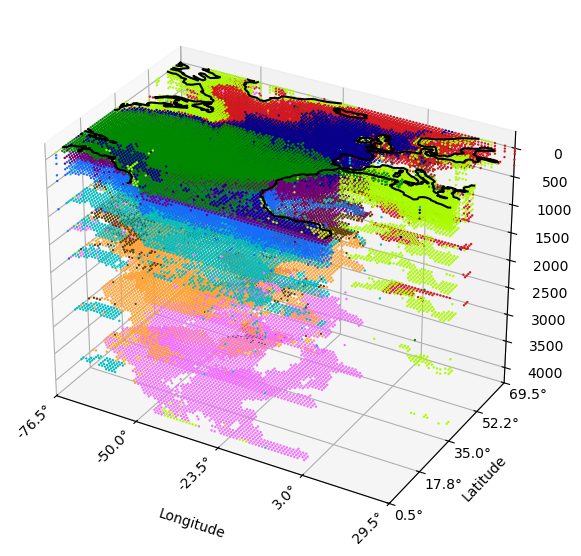

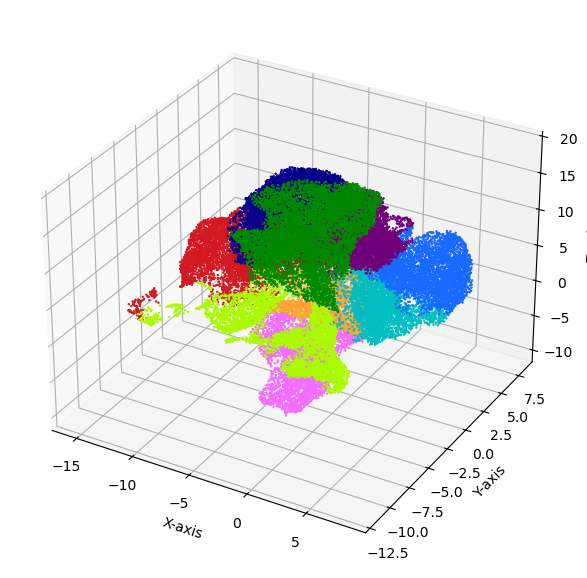

In [119]:
n_clusters = hyp_config.kmeans_umap_hyps["n_clusters"]
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_kmeans_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


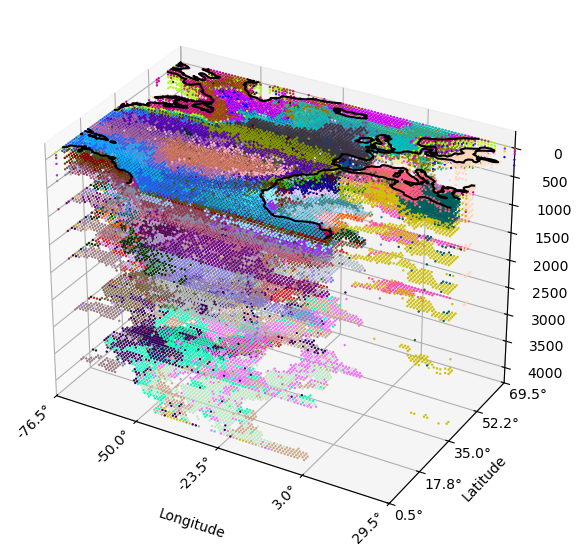

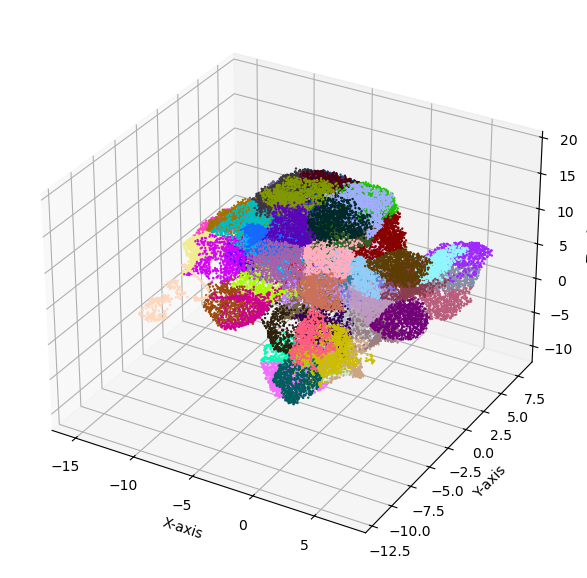

In [120]:
# Visualise highest n_clusters
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == 60]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix="_kmeans_umap_60", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# Agglomerative Ward

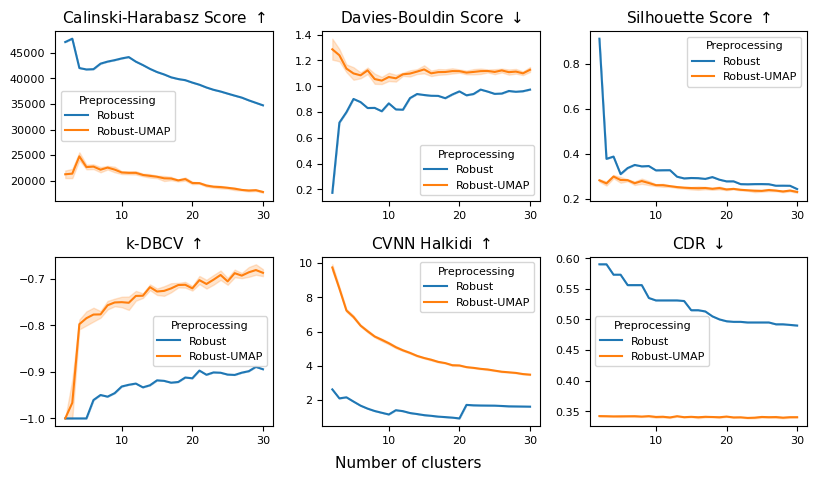

In [121]:
plot_score(df_ward, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_ward.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_ward.png", dpi=1000)
plt.show()

## Plots on original data (Robust)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


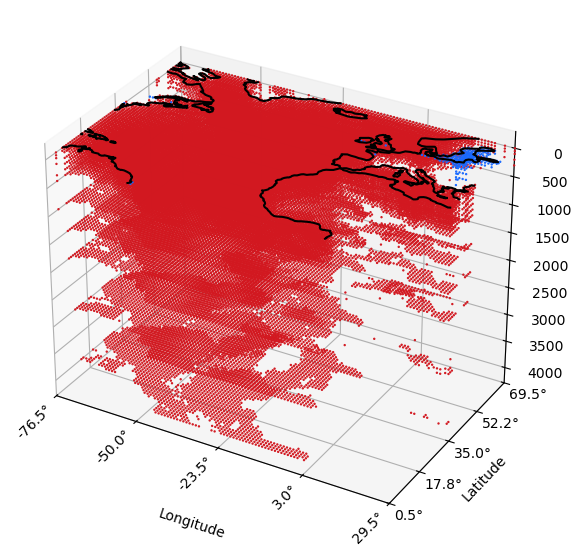

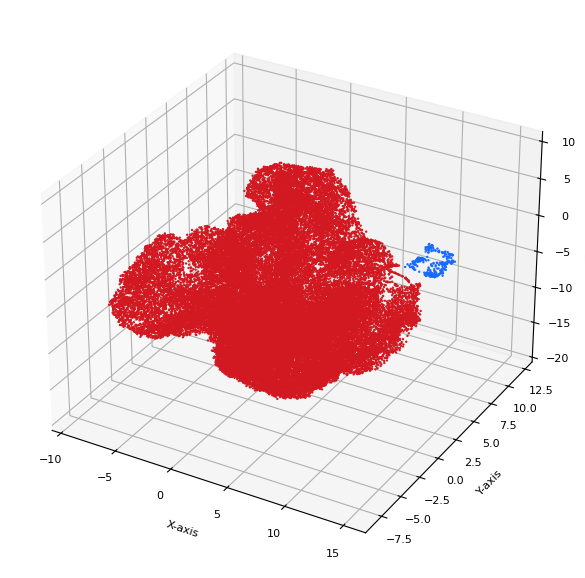

In [122]:
n_clusters = hyp_config.ward_original_hyps["n_clusters"]
temp = df_ward_labels[df_ward_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_ward_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (Robust-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


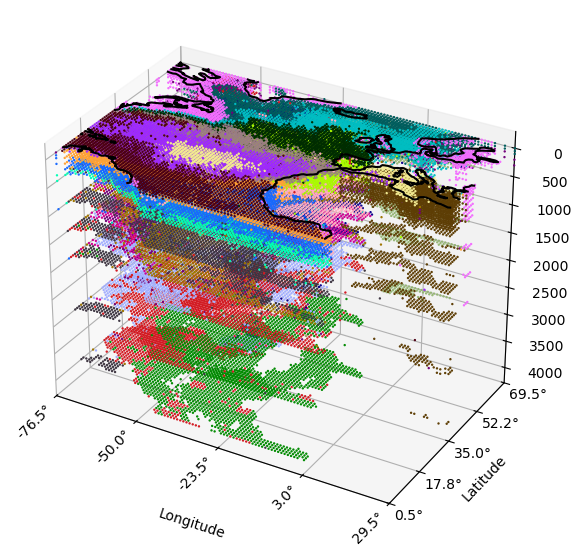

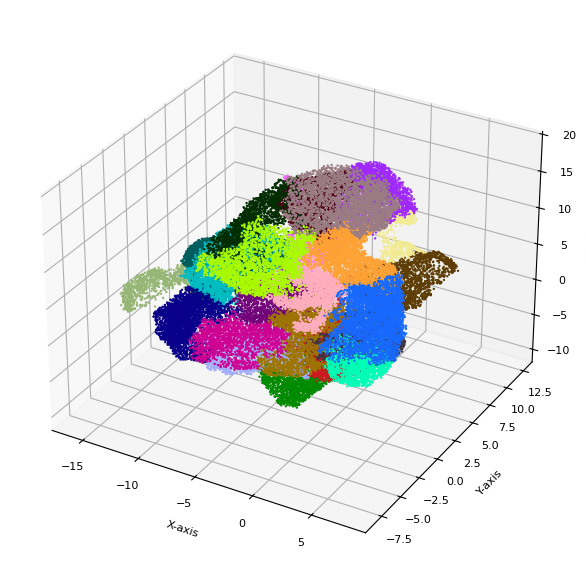

In [123]:
n_clusters = hyp_config.ward_umap_hyps["n_clusters"]
temp = df_ward_labels[df_ward_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=180, y=0, z=0, factor=-1)  # Rotate UMAP 
# temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_ward_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# Spatial Ward

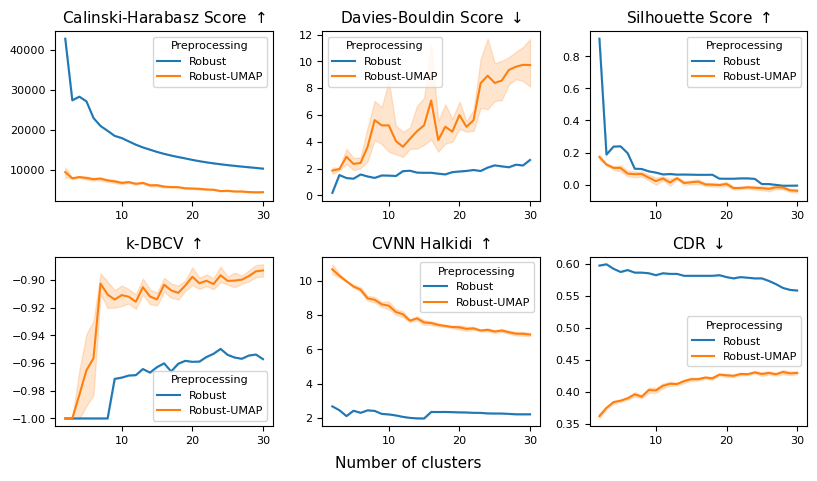

In [124]:
plot_score(df_spatial, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_spatial_ward.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_spatial_ward.png", dpi=1000)
plt.show()

## Plots on original data (Robust)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


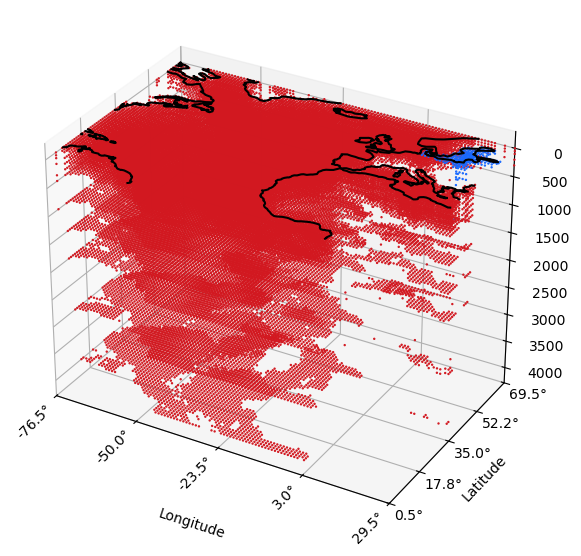

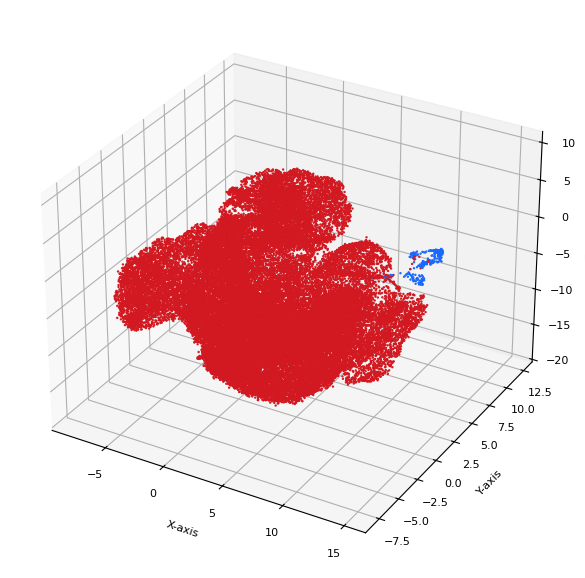

In [125]:
n_clusters = hyp_config.spatial_original_hyps["n_clusters"]
temp = df_spatial_labels[df_spatial_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_spatial_ward_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (Robust-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


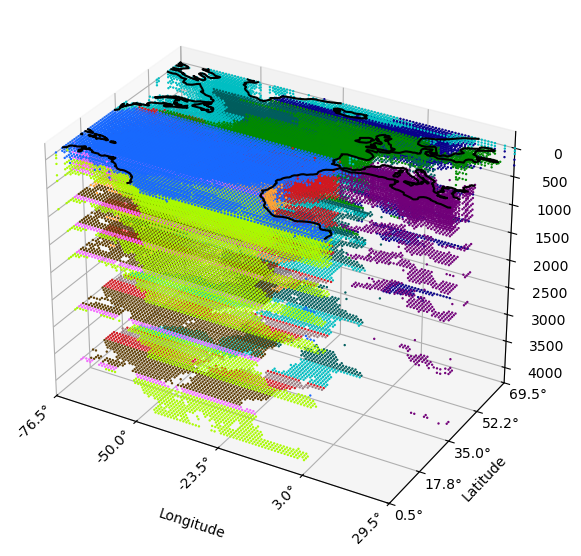

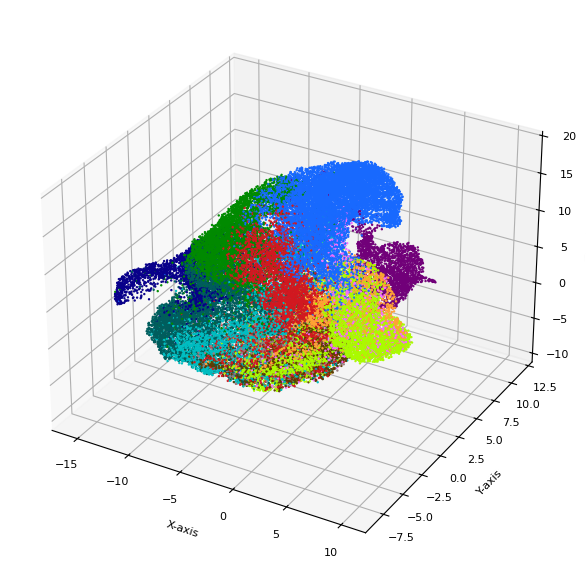

In [126]:
n_clusters = 12 # hyp_config.spatial_umap_hyps["n_clusters"]
temp = df_spatial_labels[df_spatial_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=180, y=0, z=0, factor=-1)  # Rotate UMAP 
# temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="robust_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_spatial_ward_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# DBSCAN

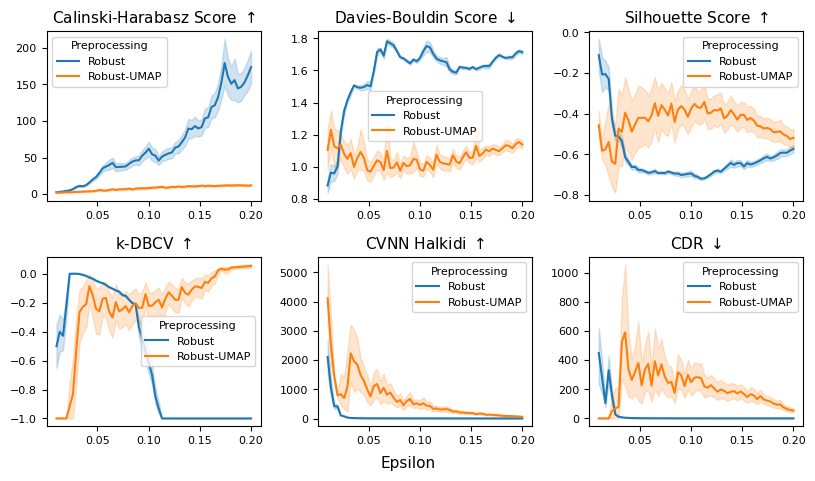

In [127]:
plot_score(df_dbscan, x="eps")
plt.savefig(f"{config.output_dir_plots}score_dbscan_eps.png")
plt.show()

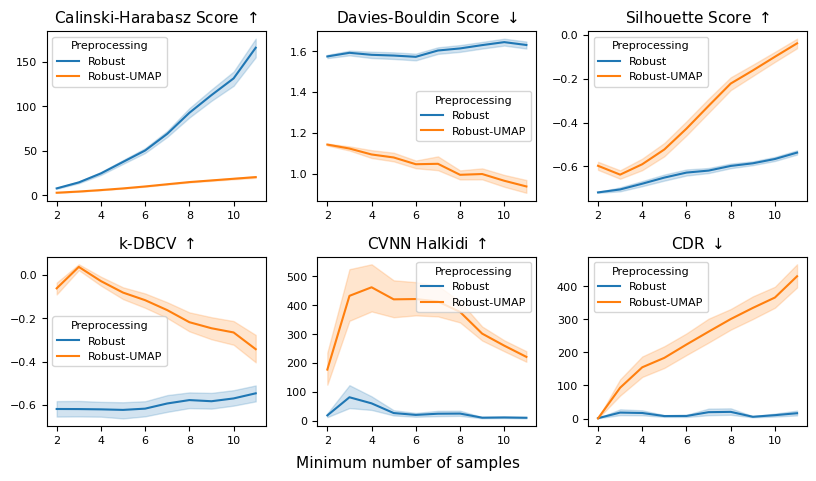

In [128]:
plot_score(df_dbscan, x="min_samples")
plt.savefig(f"{config.output_dir_plots}score_dbscan_min_samples.png")
plt.show()

## Heatmaps
The tuning of 2 parameters instead of one is more complex due to the interaction between the parameters. Therefore, considering plots displaying only one parameter is less descriptive of the actual behaviour. Therefore, we plot the following heatmap.

In [129]:
# Average scores over iterations
df_dbscan_i = df_dbscan.groupby(["eps", "min_samples", "preprocessing", "clustering"]).mean().drop("iteration", axis=1).reset_index()

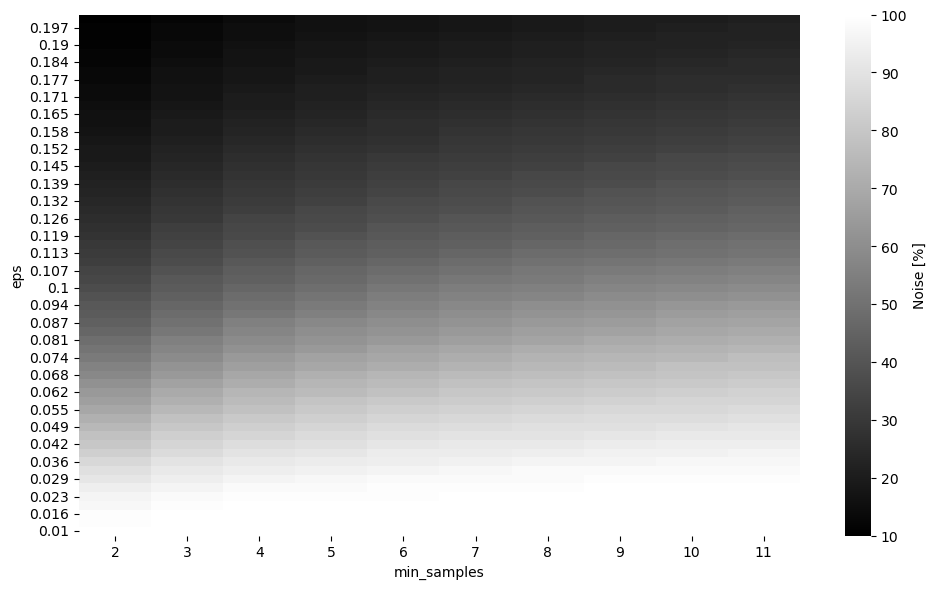

Maximum gradient for nnoise at (eps, min_samples) = (np.float64(0.052), np.float64(2.0))


C:\Users\yvjennig\.conda\envs\ocean_clustering_and_validation\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\yvjennig\.conda\envs\ocean_clustering_and_validation\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


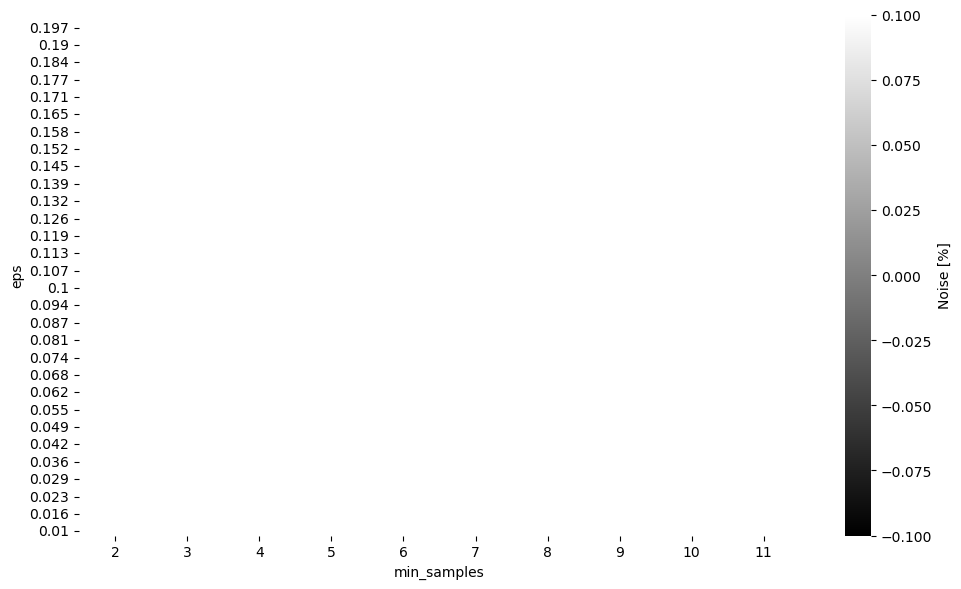

Maximum gradient (nnoise <=5) at (eps, min_samples) = (np.float64(0.052), np.float64(2.0))


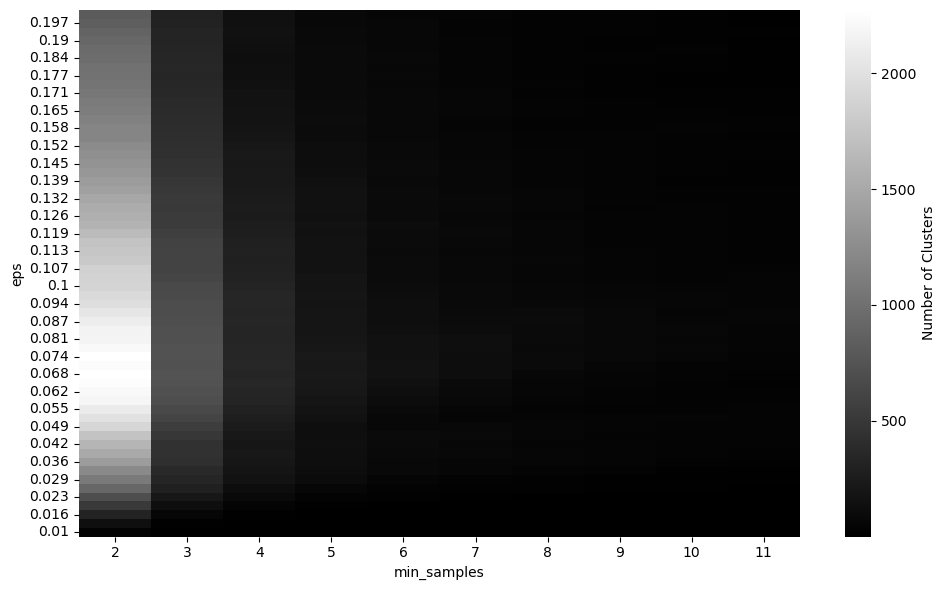

Maximum gradient at (eps, min_samples) = (np.float64(0.074), np.float64(2.0))


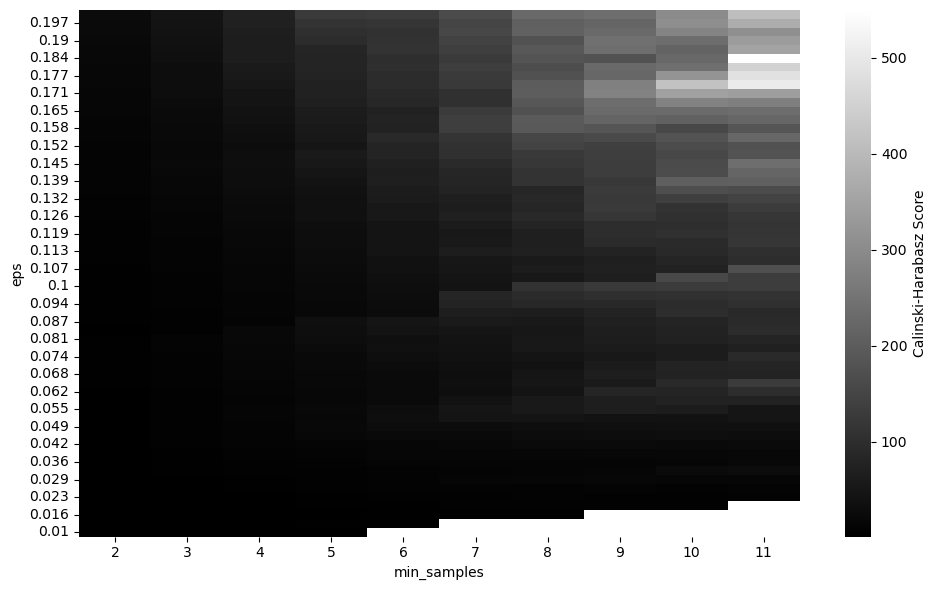

Maximum Calinski-Harabasz score here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1098  0.184           11        robust     dbscan       11.0         1.718536   

      score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
1098   50.042073     72.73      -0.383            1.74              550.0   

      kdbcv  cvnn_hal   cdr  nnoise  
1098   -1.0       3.8  0.55    25.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


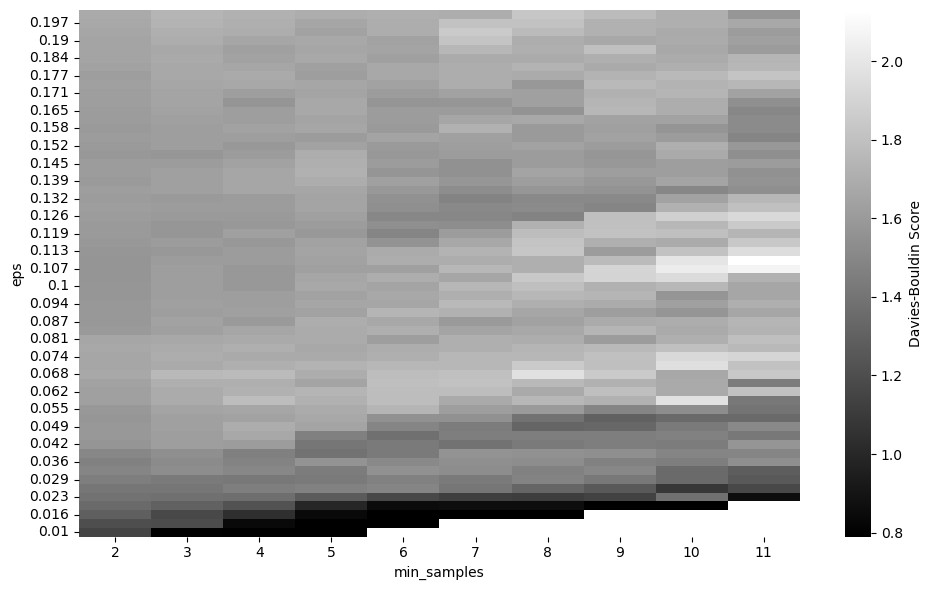

Minimum Davies-Bouldin score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
4   0.010            4        robust     dbscan        2.0         0.337874   
6   0.010            5        robust     dbscan        2.0         0.337884   
26  0.013            5        robust     dbscan        2.0         0.353711   
28  0.013            6        robust     dbscan        2.0         0.353713   
48  0.016            6        robust     dbscan        2.0         0.369808   
50  0.016            7        robust     dbscan        2.0         0.369832   
52  0.016            8        robust     dbscan        2.0         0.369555   
74  0.020            9        robust     dbscan        2.0         0.385288   
76  0.020           10        robust     dbscan        2.0         0.385448   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
4    22.182441      50.0       0.054            0.79                3.0   
6    22.201841      50.0

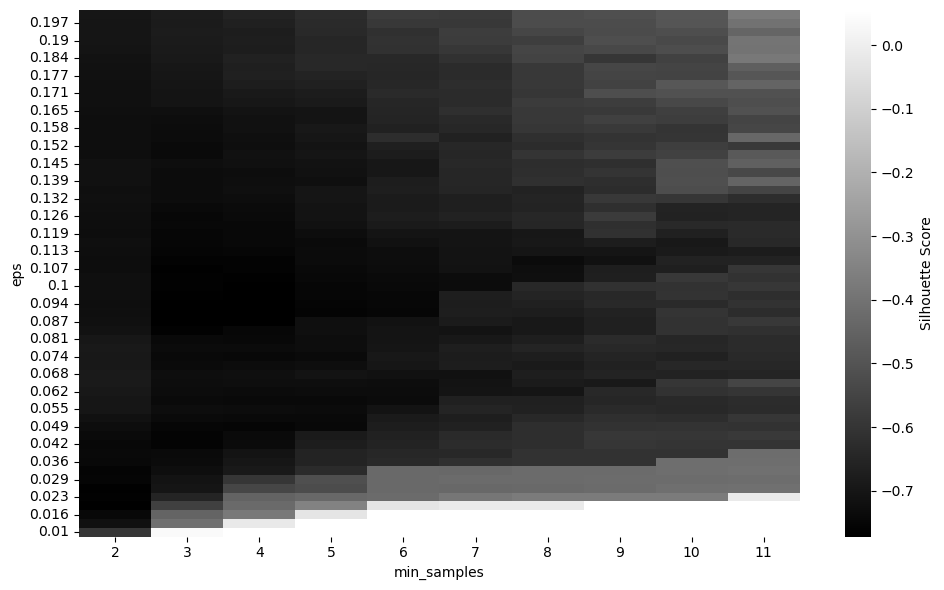

Maximum Silhouette score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
26  0.013            5        robust     dbscan        2.0         0.353711   
28  0.013            6        robust     dbscan        2.0         0.353713   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
26   22.187625      50.0       0.055            0.79                5.0   
28   22.193759      50.0       0.055            0.79                5.0   

    kdbcv  cvnn_hal  cdr  nnoise  
26   -1.0       inf  inf   100.0  
28   -1.0       inf  inf   100.0  
Maximum Silhouette score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


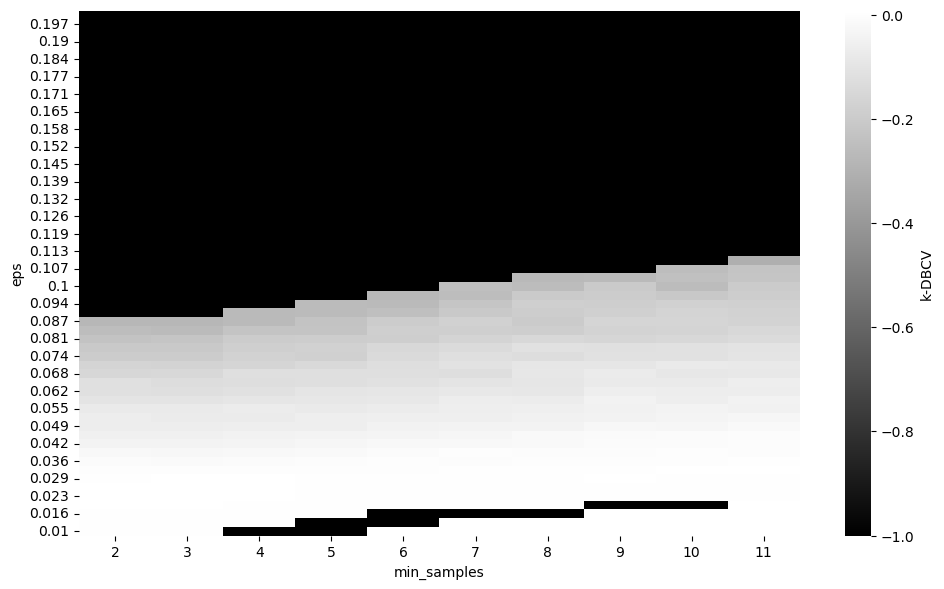

Maximum k-DBCV score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
100  0.026            2        robust     dbscan      916.0         0.419298   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
100   22.548752     99.45      -0.766            1.41                1.0   

      kdbcv  cvnn_hal   cdr  nnoise  
100  0.0075     15.29  1.49    94.0  
Maximum k-DBCV score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


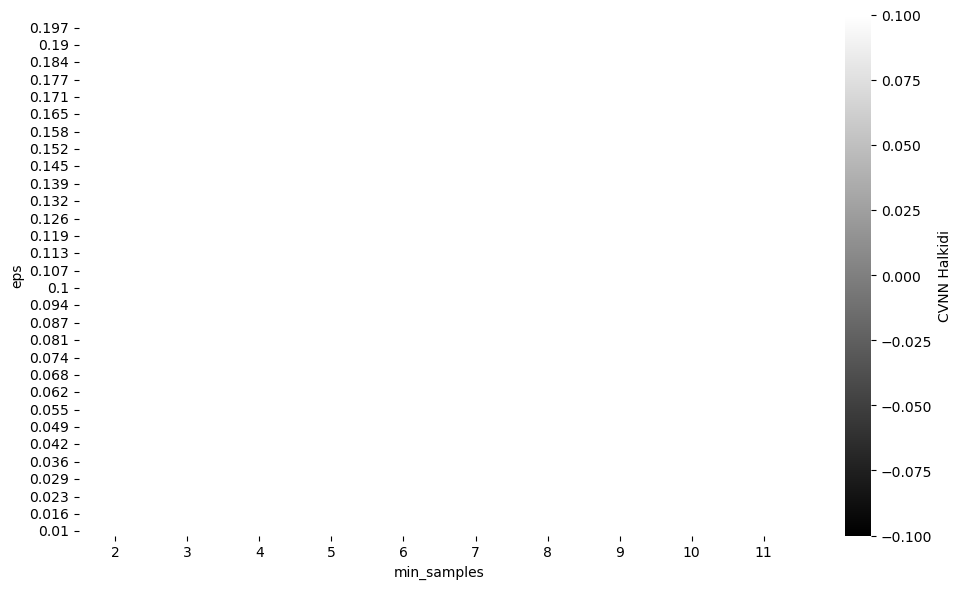

Maximum CVNN Halkidi score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
4   0.010            4        robust     dbscan        2.0         0.337874   
6   0.010            5        robust     dbscan        2.0         0.337884   
26  0.013            5        robust     dbscan        2.0         0.353711   
28  0.013            6        robust     dbscan        2.0         0.353713   
48  0.016            6        robust     dbscan        2.0         0.369808   
50  0.016            7        robust     dbscan        2.0         0.369832   
52  0.016            8        robust     dbscan        2.0         0.369555   
74  0.020            9        robust     dbscan        2.0         0.385288   
76  0.020           10        robust     dbscan        2.0         0.385448   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
4    22.182441      50.0       0.054            0.79                3.0   
6    22.201841      50.0  

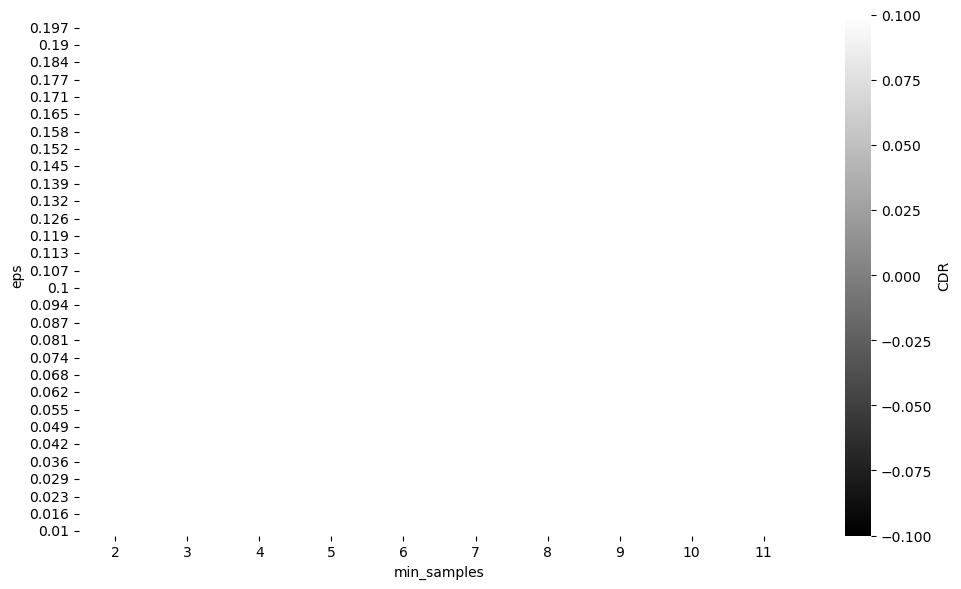

Maximum CDR score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
4   0.010            4        robust     dbscan        2.0         0.337874   
6   0.010            5        robust     dbscan        2.0         0.337884   
26  0.013            5        robust     dbscan        2.0         0.353711   
28  0.013            6        robust     dbscan        2.0         0.353713   
48  0.016            6        robust     dbscan        2.0         0.369808   
50  0.016            7        robust     dbscan        2.0         0.369832   
52  0.016            8        robust     dbscan        2.0         0.369555   
74  0.020            9        robust     dbscan        2.0         0.385288   
76  0.020           10        robust     dbscan        2.0         0.385448   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
4    22.182441      50.0       0.054            0.79                3.0   
6    22.201841      50.0       0.05

In [130]:
# Plot score heatmap for clustering on original and scores on original
preproc = "robust"
plt.rcParams["figure.figsize"] = (10, 6)

# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
temp.kdbcv = temp.kdbcv.round(4)
temp.cvnn_hal = temp.cvnn_hal.round(2)
temp.cdr = temp.cdr.round(2)
t = temp[temp.nnoise <= 5]  # Results for less than 5% noise

# Noise fraction
field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)
plt.show()
print(f"Maximum gradient for nnoise at (eps, min_samples) = {steepest_gradient}")

# Noise fraction (with mask for 5%)
field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum gradient (nnoise <=5) at (eps, min_samples) = {steepest_gradient}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")

# k-DBCV
field_kdbcv, vs_kdbcv = plot_heatmap(temp, x="min_samples", y="eps", color="kdbcv", title="", annot=False)
plt.show()
print(f"Maximum k-DBCV score here: {temp[temp.kdbcv == temp.kdbcv.max()]}")
print(f"Maximum k-DBCV score (where nnoise<=5) here: {t[t.kdbcv == t.kdbcv.max()]}")

# CVNN Halkidi
field_cvnn, vs_cvnn = plot_heatmap(temp, x="min_samples", y="eps", color="cvnn_hal", title="", annot=False)
plt.show()
print(f"Maximum CVNN Halkidi score here: {temp[temp.cvnn_hal == temp.cvnn_hal.max()]}")
print(f"Maximum CVNN Halkidi score (where nnoise<=5) here: {t[t.cvnn_hal == t.cvnn_hal.max()]}")

# CDR
field_cdr, vs_cdr = plot_heatmap(temp, x="min_samples", y="eps", color="cdr", title="", annot=False)
plt.show()
print(f"Maximum CDR score here: {temp[temp.cdr == temp.cdr.max()]}")
print(f"Maximum CDR score (where nnoise<=5) here: {t[t.cdr == t.cdr.max()]}")

In [133]:
# Optimal hyperparameter combinations according to different criteria (DBSCAN on robust)
eps_array = config.algorithms_and_hyps["dbscan"][1]["eps"]

print("Hyperparameters for DBSCAN on robust (original) data")
ch_max = temp[temp["calinski_harabasz"] == temp["calinski_harabasz"].max()].iloc[0]
sh_max = temp[temp["silhouette"] == temp["silhouette"].max()].iloc[0]
db_min = temp[temp["davies_bouldin"] == temp["davies_bouldin"].min()].iloc[0]
nc_gradient = find_steepest_gradient(temp, value_col="nclusters")
nc_steep = temp[(temp.min_samples == nc_gradient[1]) & (temp.eps.round(3) == nc_gradient[0].round(3))].iloc[0]

print(f"  Highest CH score: eps={eps_array[np.abs(eps_array - ch_max.eps).argmin()].round(8)}, min_samples={ch_max['min_samples']}, CH={ch_max['calinski_harabasz']}, DB={ch_max['davies_bouldin'].round(2)}, SH={ch_max.silhouette.round(2)}, n_clusters={ch_max.nclusters}, nnoise={ch_max.nnoise}")
print(f"  Lowest DB score: eps={eps_array[np.abs(eps_array - db_min.eps).argmin()].round(8)}, min_samples={db_min['min_samples']}, CH={db_min['calinski_harabasz']}, DB={db_min['davies_bouldin'].round(2)}, SH={db_min.silhouette.round(2)}, n_clusters={db_min.nclusters}, nnoise={db_min.nnoise}")
print(f"  Highest SH score: eps={eps_array[np.abs(eps_array - sh_max.eps).argmin()].round(8)}, min_samples={sh_max['min_samples']}, CH={sh_max['calinski_harabasz']}, DB={sh_max['davies_bouldin'].round(2)}, SH={sh_max.silhouette.round(2)}, n_clusters={sh_max.nclusters}, nnoise={sh_max.nnoise}")
print(f"  Steepest #clusters gradient: eps={eps_array[np.abs(eps_array - nc_steep.eps).argmin()].round(8)}, min_samples={nc_steep['min_samples']}, CH={nc_steep['calinski_harabasz']}, DB={nc_steep['davies_bouldin'].round(2)}, SH={nc_steep.silhouette.round(2)}, n_clusters={nc_steep.nclusters}, nnoise={nc_steep.nnoise}")

Hyperparameters for DBSCAN on robust (original) data
  Highest CH score: eps=0.10983051, min_samples=10, CH=27.0, DB=0.67, SH=0.21, n_clusters=1.0, nnoise=100.0
  Lowest DB score: eps=0.10338983, min_samples=10, CH=21.0, DB=0.67, SH=0.2, n_clusters=1.0, nnoise=100.0
  Highest SH score: eps=0.10983051, min_samples=10, CH=27.0, DB=0.67, SH=0.21, n_clusters=1.0, nnoise=100.0
  Steepest #clusters gradient: eps=0.17101695, min_samples=2, CH=4.0, DB=1.14, SH=-0.28, n_clusters=8070.0, nnoise=55.0


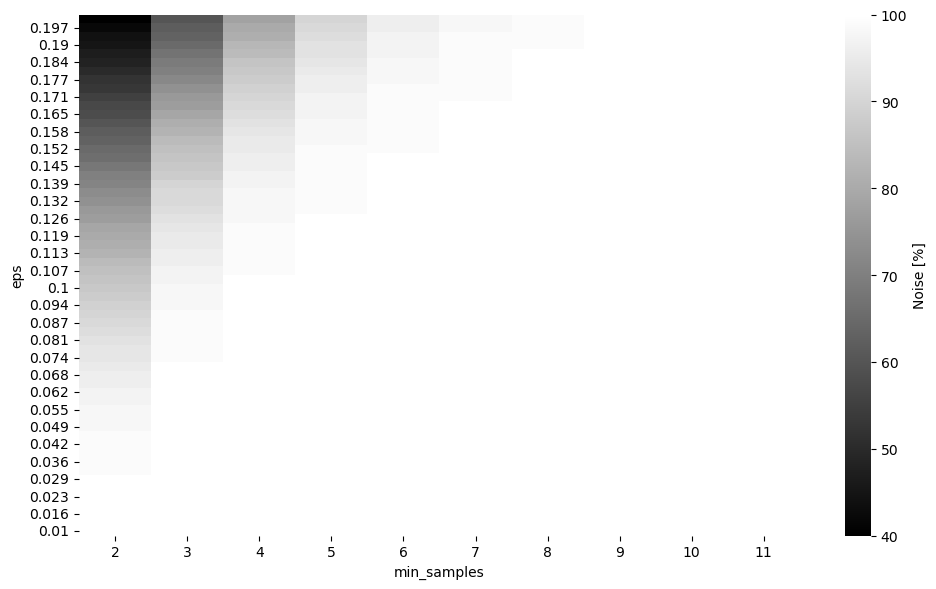

Maximum noise gradient at (eps, min_samples) = (np.float64(0.161), np.float64(2.0))


C:\Users\yvjennig\.conda\envs\ocean_clustering_and_validation\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\yvjennig\.conda\envs\ocean_clustering_and_validation\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


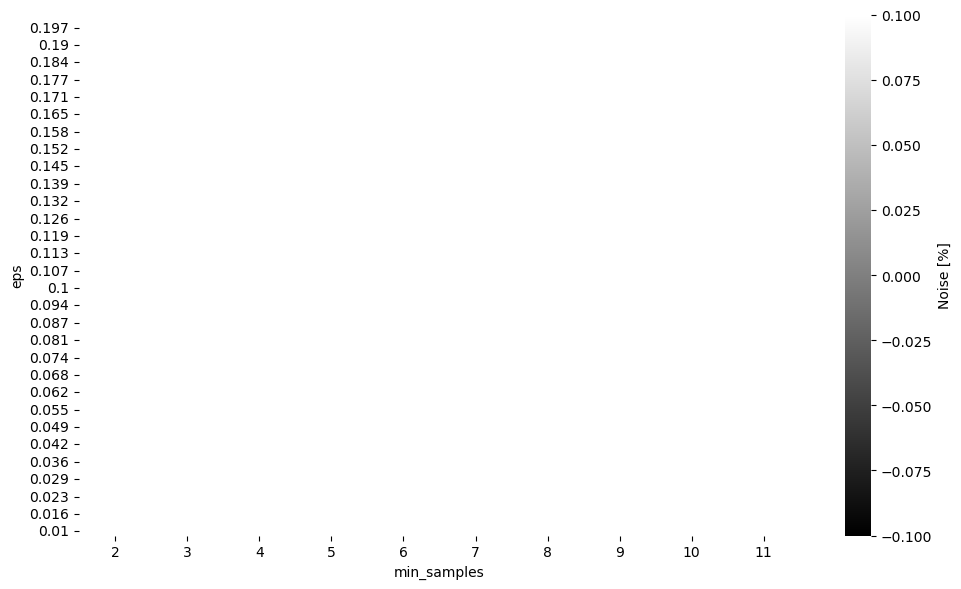

Maximum noise<5% gradient at (eps, min_samples) = (np.float64(0.161), np.float64(2.0))


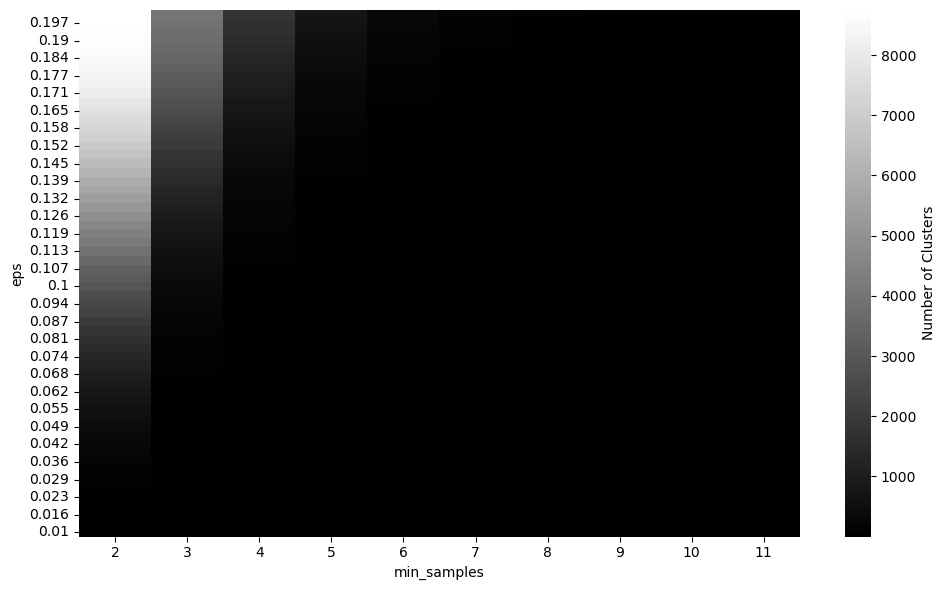

Maximum nclusters gradient at (eps, min_samples) = (np.float64(0.171), np.float64(2.0))


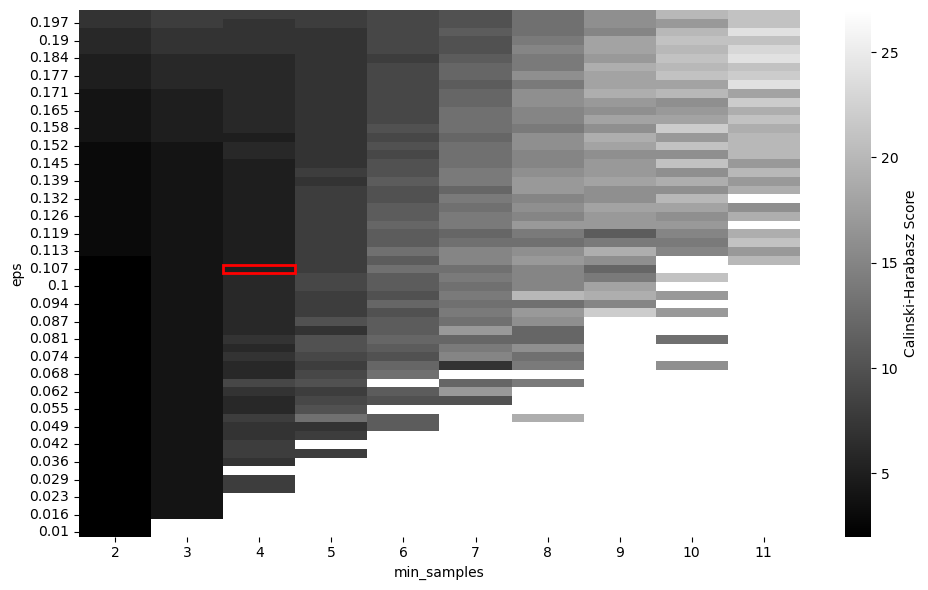

Maximum Calinski-Harabasz score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
637  0.11           10   robust_umap     dbscan        1.0        30.687765   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
637    3.038248       5.0       0.206            0.67               27.0   

     kdbcv  cvnn_hal  cdr  nnoise  
637   -1.0       inf  inf   100.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


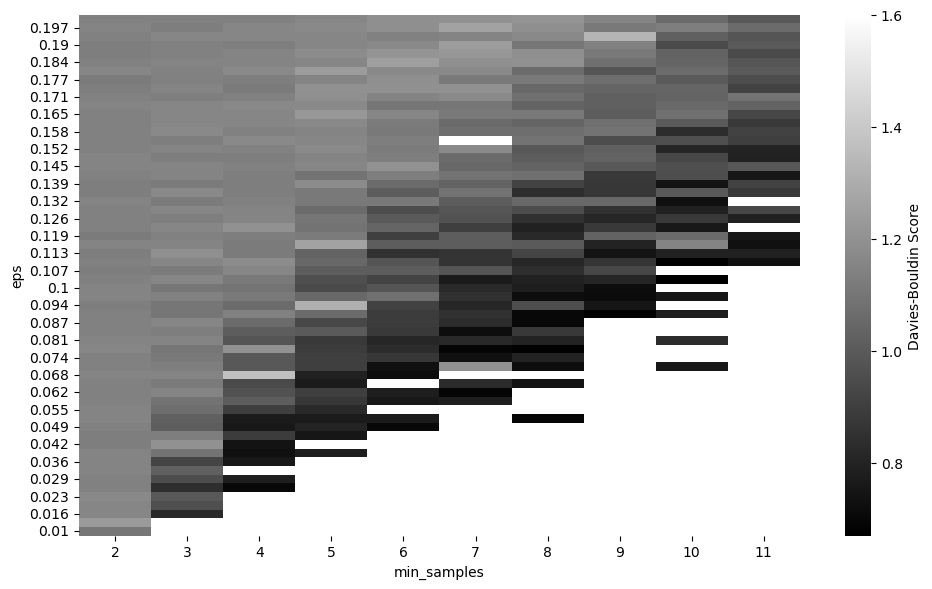

Minimum Davies-Bouldin score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
597  0.103           10   robust_umap     dbscan        1.0        30.189879   
637  0.110           10   robust_umap     dbscan        1.0        30.687765   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
597    2.775792       5.0       0.199            0.67               21.0   
637    3.038248       5.0       0.206            0.67               27.0   

     kdbcv  cvnn_hal  cdr  nnoise  
597   -1.0       inf  inf   100.0  
637   -1.0       inf  inf   100.0  
Minimum Davies-Bouldin score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


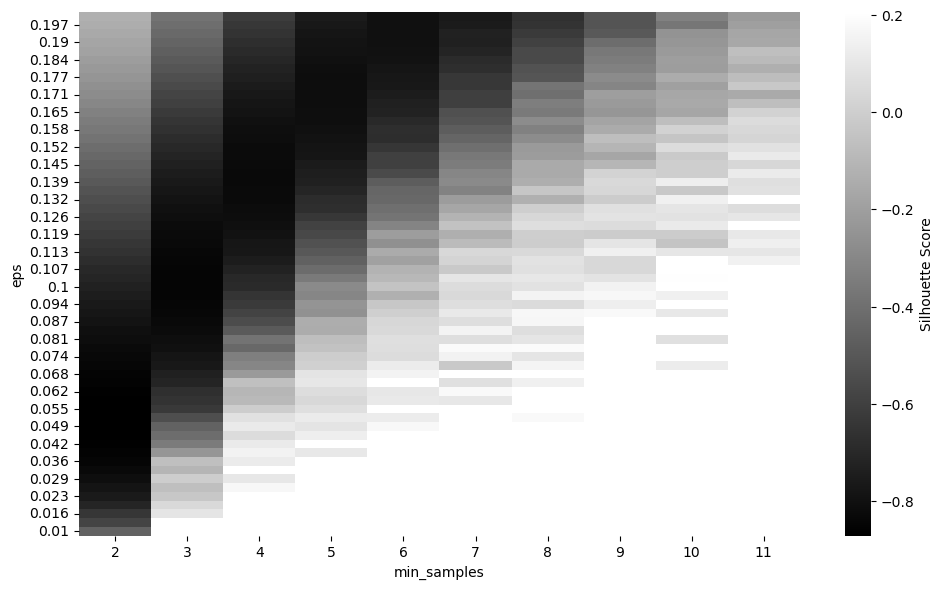

Maximum Silhouette score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
637  0.11           10   robust_umap     dbscan        1.0        30.687765   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
637    3.038248       5.0       0.206            0.67               27.0   

     kdbcv  cvnn_hal  cdr  nnoise  
637   -1.0       inf  inf   100.0  
Maximum Silhouette score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


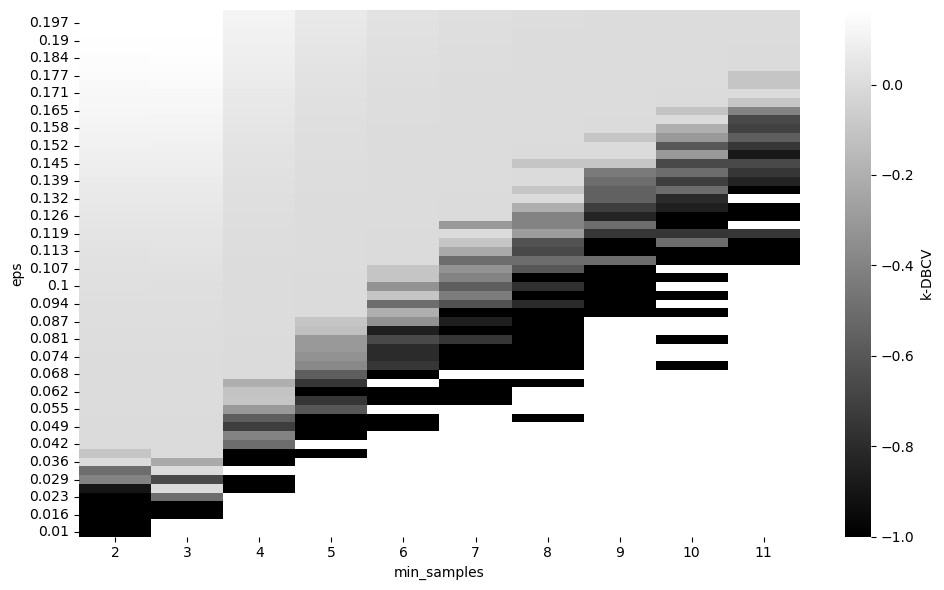

Maximum k-DBCV score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1181  0.2            2   robust_umap     dbscan     8748.0         33.30934   

      score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
1181   43.958768    99.976      -0.129            1.14                7.0   

        kdbcv  cvnn_hal     cdr  nnoise  
1181  0.16496    2.0452  0.2417    40.0  
Maximum k-DBCV score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


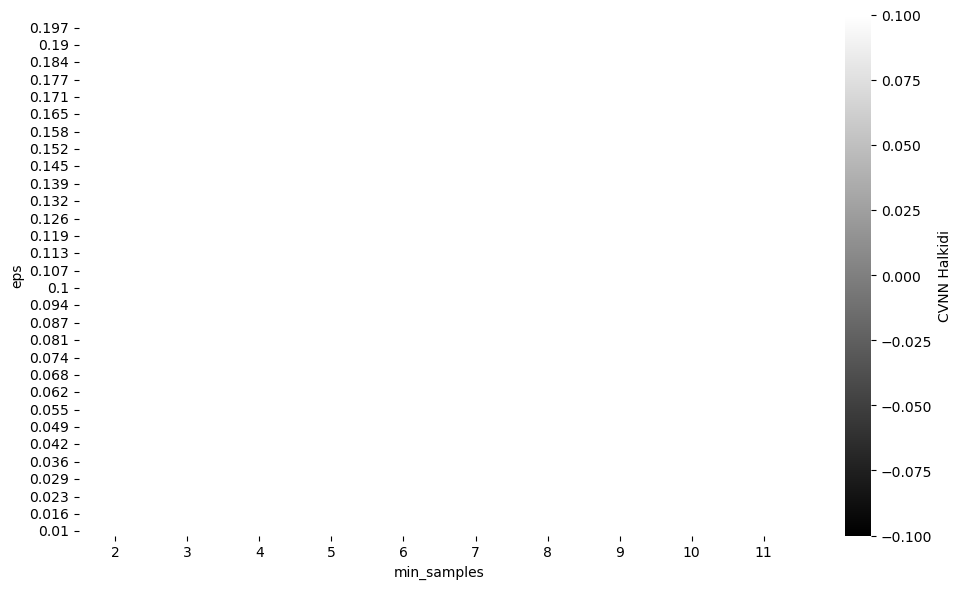

Maximum CVNN Halkidi score here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
43    0.016            3   robust_umap     dbscan        1.0        29.335349   
63    0.020            3   robust_umap     dbscan        1.0        29.246597   
83    0.023            3   robust_umap     dbscan        1.0        30.558122   
105   0.026            4   robust_umap     dbscan        1.0        27.861646   
123   0.029            3   robust_umap     dbscan        2.0        27.962226   
...     ...          ...           ...        ...        ...              ...   
977   0.165           10   robust_umap     dbscan        4.0        28.492197   
979   0.165           11   robust_umap     dbscan        3.0        28.187771   
999   0.168           11   robust_umap     dbscan        3.0        33.995736   
1039  0.174           11   robust_umap     dbscan        4.0        37.021272   
1059  0.177           11   robust_umap     dbscan        4.0        28.83377

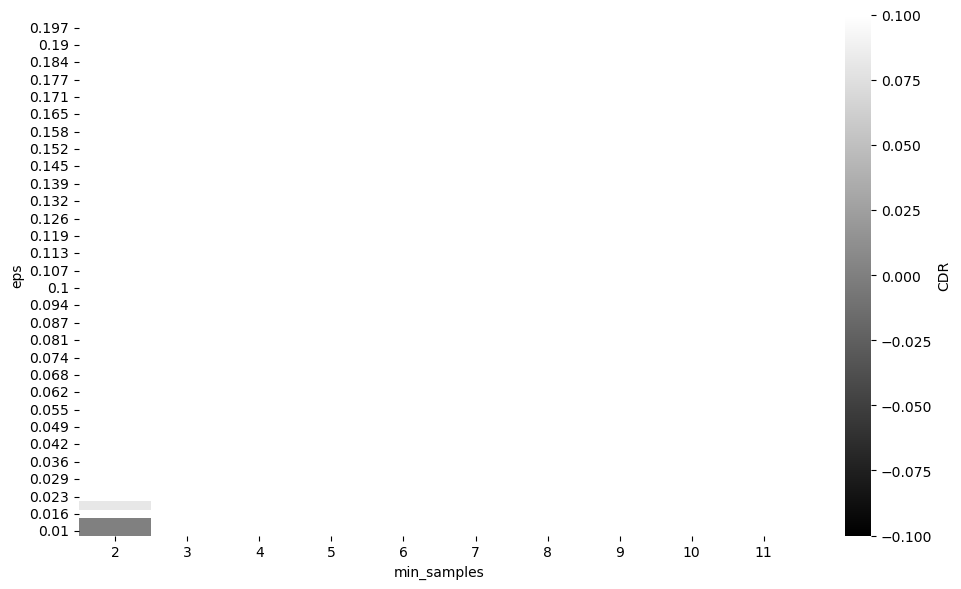

Maximum CDR score here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
43    0.016            3   robust_umap     dbscan        1.0        29.335349   
63    0.020            3   robust_umap     dbscan        1.0        29.246597   
83    0.023            3   robust_umap     dbscan        1.0        30.558122   
105   0.026            4   robust_umap     dbscan        1.0        27.861646   
123   0.029            3   robust_umap     dbscan        2.0        27.962226   
...     ...          ...           ...        ...        ...              ...   
977   0.165           10   robust_umap     dbscan        4.0        28.492197   
979   0.165           11   robust_umap     dbscan        3.0        28.187771   
999   0.168           11   robust_umap     dbscan        3.0        33.995736   
1039  0.174           11   robust_umap     dbscan        4.0        37.021272   
1059  0.177           11   robust_umap     dbscan        4.0        28.833778   

   

In [134]:
# Plot score heatmap for clustering on embedding
preproc = "robust_umap"
plt.rcParams["figure.figsize"] = (10, 6)

# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
t = temp[temp.nnoise <= 5]

# Noise fraction
field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False) 
plt.show()
print(f"Maximum noise gradient at (eps, min_samples) = {steepest_gradient}")

# Noise fraction (with mask for 5%)
field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum noise<5% gradient at (eps, min_samples) = {steepest_gradient}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum nclusters gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(hyp_config.dbscan_umap_hyps["eps"], 3), hyp_config.dbscan_umap_hyps["min_samples"]))
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_calinski.png")
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_davies_bouldin.png")
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_silhouette.png")
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")

# k-DBCV
field_kdbcv, vs_kdbcv = plot_heatmap(temp, x="min_samples", y="eps", color="kdbcv", title="", annot=False)
plt.show()
print(f"Maximum k-DBCV score here: {temp[temp.kdbcv == temp.kdbcv.max()]}")
print(f"Maximum k-DBCV score (where nnoise<=5) here: {t[t.kdbcv == t.kdbcv.max()]}")

# CVNN Halkidi
field_cvnn, vs_cvnn = plot_heatmap(temp, x="min_samples", y="eps", color="cvnn_hal", title="", annot=False)
plt.show()
print(f"Maximum CVNN Halkidi score here: {temp[temp.cvnn_hal == temp.cvnn_hal.max()]}")
print(f"Maximum CVNN Halkidi score (where nnoise<=5) here: {t[t.cvnn_hal == t.cvnn_hal.max()]}")

# CDR
field_cdr, vs_cdr = plot_heatmap(temp, x="min_samples", y="eps", color="cdr", title="", annot=False)
plt.show()
print(f"Maximum CDR score here: {temp[temp.cdr == temp.cdr.max()]}")
print(f"Maximum CDR score (where nnoise<=5) here: {t[t.cdr == t.cdr.max()]}")

In [135]:
# Optimal hyperparameter combinations according to different criteria (DBSCAN on robust-UMAP)
eps_array = config.algorithms_and_hyps["dbscan"][1]["eps"]

print("Hyperparameters for DBSCAN on robust_umap (embedded) data")
ch_max = temp[temp["calinski_harabasz"] == temp["calinski_harabasz"].max()].iloc[0]
sh_max = temp[temp["silhouette"] == temp["silhouette"].max()].iloc[0]
db_min = temp[temp["davies_bouldin"] == temp["davies_bouldin"].min()].iloc[0]
nc_gradient = find_steepest_gradient(temp, value_col="nclusters")
nc_steep = temp[(temp.min_samples == nc_gradient[1]) & (temp.eps.round(3) == nc_gradient[0].round(3))].iloc[0]

print(f"  Highest CH score: eps={eps_array[np.abs(eps_array - ch_max.eps).argmin()].round(8)}, min_samples={ch_max['min_samples']}, CH={ch_max['calinski_harabasz']}, DB={ch_max['davies_bouldin'].round(2)}, SH={ch_max.silhouette.round(2)}, n_clusters={ch_max.nclusters}, nnoise={ch_max.nnoise}")
print(f"  Lowest DB score: eps={eps_array[np.abs(eps_array - db_min.eps).argmin()].round(8)}, min_samples={db_min['min_samples']}, CH={db_min['calinski_harabasz']}, DB={db_min['davies_bouldin'].round(2)}, SH={db_min.silhouette.round(2)}, n_clusters={db_min.nclusters}, nnoise={db_min.nnoise}")
print(f"  Highest SH score: eps={eps_array[np.abs(eps_array - sh_max.eps).argmin()].round(8)}, min_samples={sh_max['min_samples']}, CH={sh_max['calinski_harabasz']}, DB={sh_max['davies_bouldin'].round(2)}, SH={sh_max.silhouette.round(2)}, n_clusters={sh_max.nclusters}, nnoise={sh_max.nnoise}")
print(f"  Steepest #clusters gradient: eps={eps_array[np.abs(eps_array - nc_steep.eps).argmin()].round(8)}, min_samples={nc_steep['min_samples']}, CH={nc_steep['calinski_harabasz']}, DB={nc_steep['davies_bouldin'].round(2)}, SH={nc_steep.silhouette.round(2)}, n_clusters={nc_steep.nclusters}, nnoise={nc_steep.nnoise}")

Hyperparameters for DBSCAN on robust_umap (embedded) data
  Highest CH score: eps=0.10983051, min_samples=10, CH=27.0, DB=0.67, SH=0.21, n_clusters=1.0, nnoise=100.0
  Lowest DB score: eps=0.10338983, min_samples=10, CH=21.0, DB=0.67, SH=0.2, n_clusters=1.0, nnoise=100.0
  Highest SH score: eps=0.10983051, min_samples=10, CH=27.0, DB=0.67, SH=0.21, n_clusters=1.0, nnoise=100.0
  Steepest #clusters gradient: eps=0.17101695, min_samples=2, CH=4.0, DB=1.14, SH=-0.28, n_clusters=8070.0, nnoise=55.0


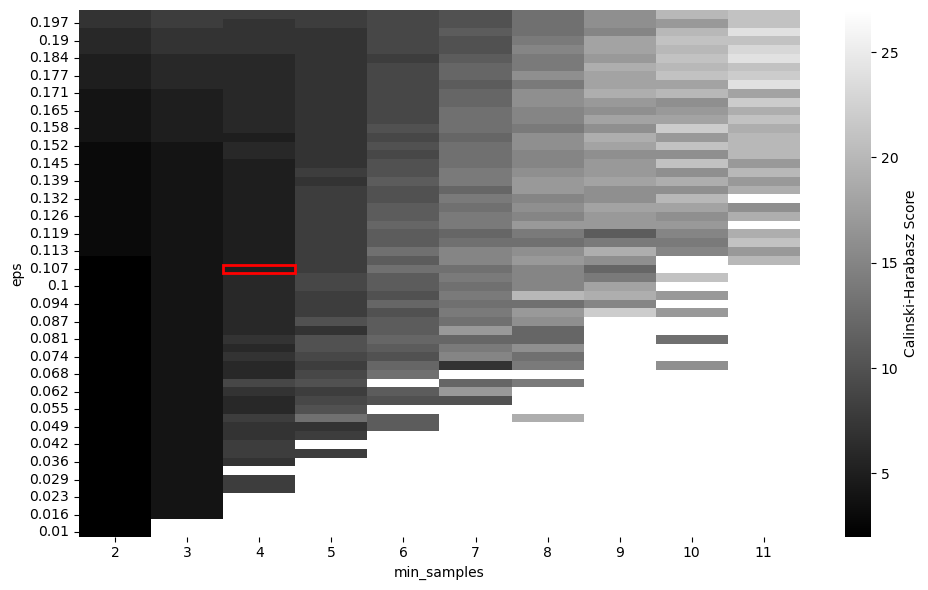

Maximum Calinski-Harabasz score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
637  0.11           10   robust_umap     dbscan        1.0        30.687765   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
637    3.038248       5.0       0.206            0.67               27.0   

     kdbcv  cvnn_hal  cdr  nnoise  
637   -1.0       inf  inf   100.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here: Empty DataFrame
Columns: [eps, min_samples, preprocessing, clustering, nclusters, clustering_time, score_time, confetti, silhouette, davies_bouldin, calinski_harabasz, kdbcv, cvnn_hal, cdr, nnoise]
Index: []


In [136]:
# Plot CH heatmap for DBSCAN on robust-UMAP
preproc = "robust_umap"

# Figure size
plt.rcParams["figure.figsize"] = (10, 10*0.6)  

# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
t = temp[temp.nnoise <= 5]

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(hyp_config.dbscan_umap_hyps["eps"], 3), hyp_config.dbscan_umap_hyps["min_samples"]))
plt.savefig(f"{config.output_dir_plots_high_res}{preproc}_dbscan_sweep_calinski.png", dpi=1000)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")


## Plots on original data (Robust)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


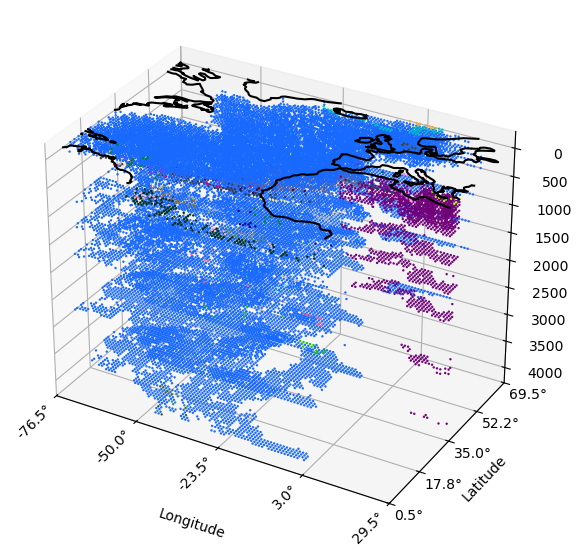

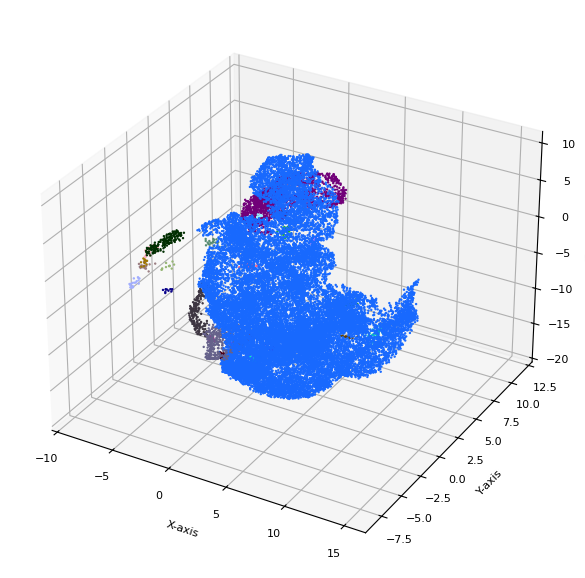

In [137]:
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_original_hyps, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"robust": "label"})

temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label

coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_dbscan_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (Robust-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


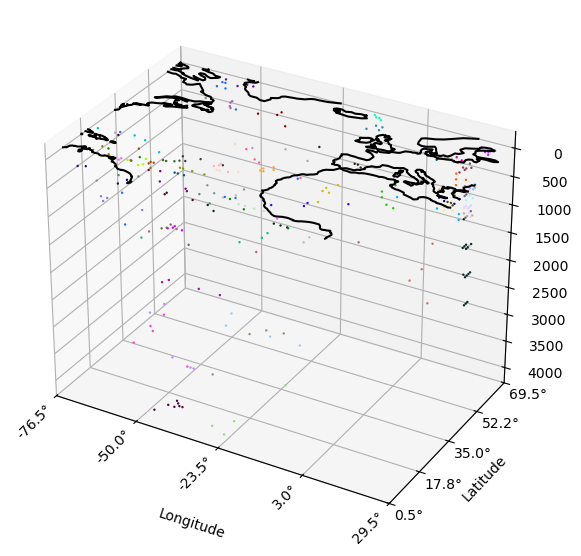

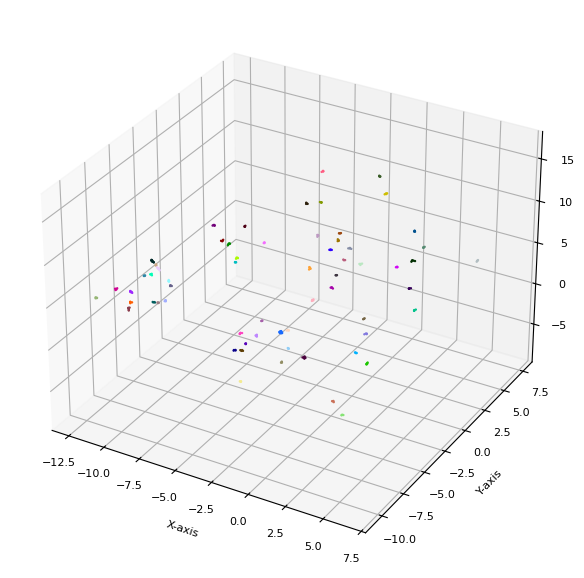

In [138]:
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_umap_hyps, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"robust_umap": "label"})

temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_dbscan_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Confetti Plot

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


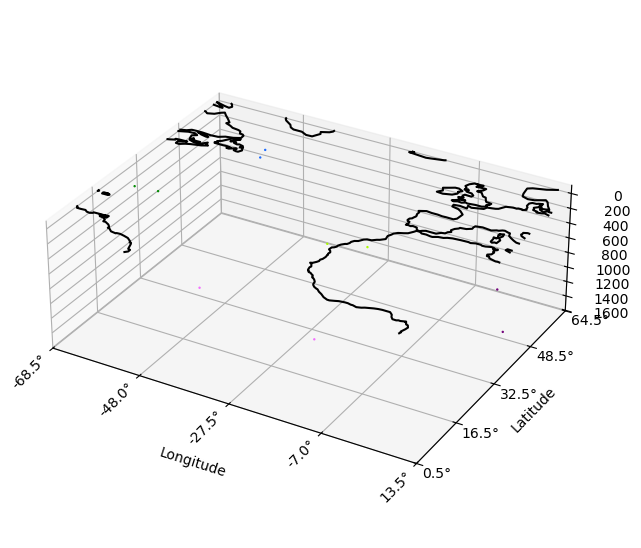

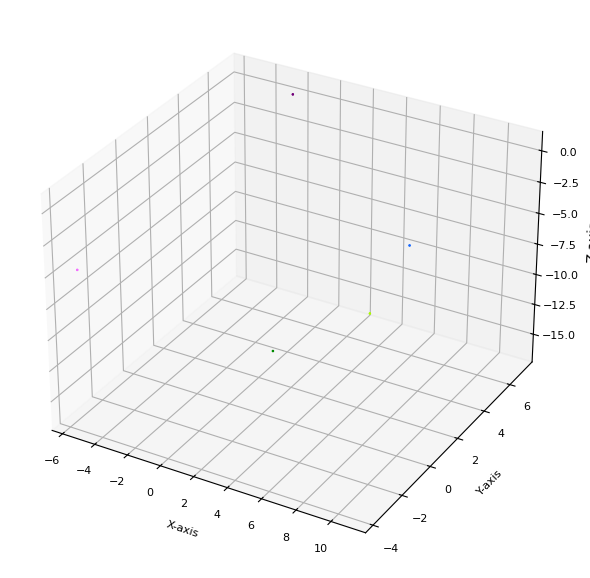

In [139]:
query_str = get_query_string_hyps_filter(hyp_dict={"eps": 0.01, "min_samples": 2}, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"robust_umap": "label"})

temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label
temp[["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)

coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_confetti", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)